In [1]:
from resources.imports import *

from resources.MLdata import *
from resources.MLfunc import *

from resources.calculations import get_ductileData, calcUT

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from scipy.stats import norm
from scipy.optimize import minimize

import copy
import subprocess

In [2]:
os.chdir("C:\\temp")

DAT = DATA(path=1, 
           path_add="",
           load=True, 
           LAT="FCC", 
           dis="disNodes", 
           dN=0.2, 
           model="MLP",
           freq=False, 
           format=1)

LAT = DAT.LAT
nnx = 16
l = 10
mode = "ductile"
material = "ti"
rD = 0.2
dis = "disNodes"
dN = 0.2
distribution = "opt"
target = "all"
initial = 1
nJobs = 1
CPUs = 12
Fout = 100
Hout = 200
pDir = f"{DAT.PATH}/Opt"

argv = f"{LAT} {nnx} {l} {mode} {material} {rD} {dis} {dN} {distribution} {target} {initial} {nJobs} {CPUs} {Fout} {Hout} {pDir} OptLoop"

In [3]:
np.concatenate((DAT.train_in, DAT.val_in, DAT.test_in)).shape, np.concatenate((DAT.train_out, DAT.val_out, DAT.test_out)).shape

((986, 900), (986, 201))

In [4]:
DAT.perIN_df.shape, DAT.perIN.shape, DAT.perIN_r.shape

((1500, 1), (900,), (1500,))

In [5]:
DAT.IN_df.shape, DAT.OUT_df.shape, DAT.dIN_df.shape, DAT.dOUT_df.shape

test = DAT.IN_df - DAT.IN_df.iloc[0].values
test = test.loc[:, ~(test == 0.0).all()].sort_index()
check = abs(abs(test).sum(axis=0))
check2 = check < 0.1
check2[check2 == True]

Series([], dtype: bool)

In [6]:
DAT.dIN_df.shape, DAT.train_in.shape

((999, 900), (712, 900))

In [7]:
strain_curve = DAT.perOUT_df.x.to_numpy()
ducts = []
strengths = []
for _, row in DAT.OUT_df.iterrows():
    ducts.append(strain_curve[int(row.tolist()[0])])
    strengths.append(max(row.tolist()[1:]))

ducts, strengths = np.array(ducts), np.array(strengths)
xs_now = DAT.dIN_df.to_numpy() #np.concatenate((np.array([[0]*58]), DAT.INf_df.to_numpy()))

ducts.shape, strengths.shape, xs_now.shape

((999,), (999,), (999, 900))

# Bayesian Optimization


--- Running Bayesian Optimization ---
Loading 999 initial data points to warm-start the optimizer.


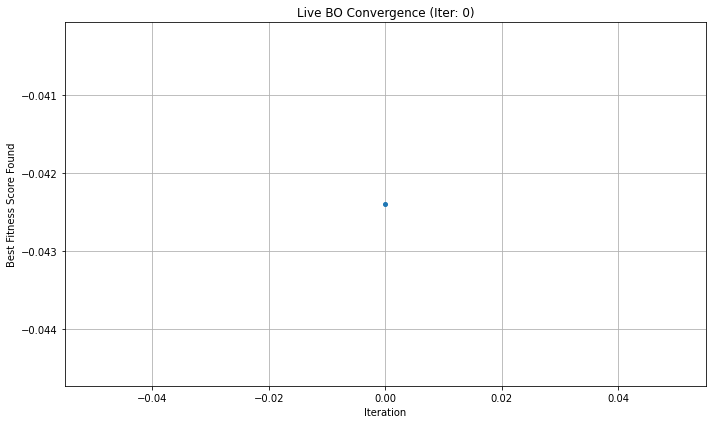

In [ ]:
class BayesianOptimization:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        bounds=(-0.2, 0.2),
        constraint_fn=None,
        log_file=f"{DAT.PATH}/Opt/BO_log.txt",
        X_initial=None,
        y_initial=None
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.low_bound, self.high_bound = bounds
        self.constraint_fn = constraint_fn
        self.log_file = log_file
        
        self.X_sample = []
        self.Y_sample = []

        if X_initial is not None and y_initial is not None:
            print(f"Loading {len(y_initial)} initial data points to warm-start the optimizer.")
            for i in range(len(y_initial)):
                self.X_sample.append(X_initial[i].flatten())
            self.Y_sample = list(y_initial)
        
        self.n_features = np.prod(self.input_shape)
        self.bounds_1d = np.array([[self.low_bound, self.high_bound]] * self.n_features)
        
        kernel = ConstantKernel(1.0) * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=0.1)
        self.gp_model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-6,
            normalize_y=True,
            n_restarts_optimizer=10
        )
        
        if not os.path.exists(f"{DAT.PATH}/Opt"):
            os.makedirs(f"{DAT.PATH}/Opt")
        if os.path.exists(self.log_file):
            os.remove(self.log_file)

    def _get_acquisition_function(self, X):
        mu, sigma = self.gp_model.predict(X, return_std=True)
        sigma = sigma.reshape(-1, 1)
        
        y_best = np.min(self.Y_sample)
        
        imp = y_best - mu
        Z = imp / (sigma + 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma < 1e-9] = 0.0
        
        return ei.flatten()

    def _optimize_acquisition(self, n_restarts=25):
        def objective(x):
            return -self._get_acquisition_function(x.reshape(1, -1))

        random_starts = np.random.uniform(self.low_bound, self.high_bound, size=(n_restarts, self.n_features))
        
        best_x = None
        best_val = np.inf

        for x0 in random_starts:
            res = minimize(
                fun=objective,
                x0=x0,
                bounds=self.bounds_1d,
                method='L-BFGS-B'
            )
            if res.fun < best_val:
                best_val = res.fun
                best_x = res.x
                
        return best_x.reshape(self.input_shape)

    def _report_progress(self, iteration, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Iteration: {iteration:4} | Best Fitness Found: {np.min(history):10.4f}\n")
        
        plt.clf()
        plt.plot(history, marker='o', linestyle='-', markersize=4)
        plt.title(f'Live BO Convergence (Iter: {iteration})')
        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness Score Found')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_iterations=50, n_initial_points=10):
        if not self.X_sample:
            print(f"No initial data provided. Running {n_initial_points} initial random evaluations...")
            for _ in range(n_initial_points):
                x_init = np.random.uniform(self.low_bound, self.high_bound, size=self.input_shape)
                y_init = self.fitness_fn(x_init)
                self.X_sample.append(x_init.flatten())
                self.Y_sample.append(y_init)
        
        history = [np.min(self.Y_sample)]

        plt.ion()
        fig = plt.figure(figsize=(10, 6))
        self._report_progress(0, history)

        for i in range(1, n_iterations + 1):
            X_arr = np.array(self.X_sample)
            Y_arr = np.array(self.Y_sample)
            self.gp_model.fit(X_arr, Y_arr)
            
            next_point_to_sample = self._optimize_acquisition()
            
            if self.constraint_fn and not self.constraint_fn(next_point_to_sample):
                 next_point_to_sample = np.random.uniform(self.low_bound, self.high_bound, size=self.input_shape)
            
            y_next = self.fitness_fn(next_point_to_sample, i)
            
            self.X_sample.append(next_point_to_sample.flatten())
            self.Y_sample.append(y_next)
            
            history.append(np.min(self.Y_sample))
            self._report_progress(i, history)

        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        best_idx = np.argmin(self.Y_sample)
        return self.X_sample[best_idx].reshape(self.input_shape), self.Y_sample[best_idx]


INPUT_SHAPE = xs_now[0].shape
LOWER_BOUND = min(xs_now.flatten())
UPPER_BOUND = max(xs_now.flatten())

def objective_fn(individual, iter):
    score = FEA_run(individual, iter)
    return -score if np.isfinite(score) else np.inf

def FEA_run(x_new, iter):
    new_sample_file = f"{DAT.PATH}/Opt/BO_sample{iter}.txt"
    np.savetxt(new_sample_file, x_new.flatten()[np.newaxis], fmt='%.6f')

    try:
        print("-> Running Abaqus pre-processing and simulation...")
        abq_argv = f"{argv} {iter}"
        
        abq_run_file = r"C:\\Users\\exy053\\Documents\\p1git-Lattices\\SIMscripts\\A1_FractureToughness-Ductility.py"
        abq_run_cmd = f"abaqus cae noGUI={abq_run_file} -- {abq_argv}"
        subprocess.run(abq_run_cmd, shell=True, check=True)

        abq_inPP_file = r"C:\\Users\\exy053\\Documents\\p1git-Lattices\\SIMscripts\\A2_INpostProcess.py"
        abq_inPP_cmd = f"abaqus cae noGUI={abq_inPP_file} -- {abq_argv}"
        subprocess.run(abq_inPP_cmd, shell=True, check=True)

        abq_outPP_file = r"C:\\Users\\exy053\\Documents\\p1git-Lattices\\SIMscripts\\A2_OUTpostProcess.py"
        abq_outPP_cmd = f"abaqus cae noGUI={abq_outPP_file} -- {abq_argv}"
        subprocess.run(abq_outPP_cmd, shell=True, check=True)

        CSVout = f"{DAT.PATH}/Opt/transfer/OUT-Ductile-{LAT}-{int(nnx)}-{int(dN*100)}{dis}-{distribution}-{target}-{iter}.csv"
        UTdf = get_ductileData(CSVout, crit=0.25)
        ductility, strength, stiffness = calcUT(UTdf)

        score = ductility
        return score
    
    except subprocess.CalledProcessError as e:
        print(f"!!! An Abaqus process failed: {e}")
        return np.inf

    except Exception as e:
        print(f"!!! An unexpected error occurred in the FEA workflow: {e}")
        return np.inf

def constraint_check(individual):
    lim = [np.min(xs_now.flatten()), np.max(xs_now.flatten())]
    return np.max(np.abs(individual)) < lim[1]

# 2. RUN THE ALGORITHM
print("\n--- Running Bayesian Optimization ---")
bo_optimizer = BayesianOptimization(
    fitness_fn=objective_fn,
    input_shape=INPUT_SHAPE,
    bounds=(LOWER_BOUND, UPPER_BOUND),
    constraint_fn=None,
    X_initial=xs_now,
    y_initial=-ducts
)

# Run with 10 random starting points, then 40 intelligent iterations
solution, score = bo_optimizer.run(n_iterations=20)

print(f"\nBO Best Score: {-score:.6f}")


# Genetic Algorithm

In [ ]:
class GeneticAlgorithm:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        pop_size=50,
        bounds=(-0.2, 0.2),
        evaluation_mode='surrogate',
        constraint_fn=None,
        log_file='ga_log.txt'
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.pop_size = pop_size
        self.low_bound, self.high_bound = bounds
        self.evaluation_mode = evaluation_mode
        self.constraint_fn = constraint_fn
        self.log_file = log_file
        
        self.population = np.random.uniform(
            self.low_bound,
            self.high_bound,
            size=(self.pop_size,) + self.input_shape
        )
        
        if self.evaluation_mode == 'fea':
            self.fitness_cache = {}
            
        if os.path.exists(self.log_file):
            os.remove(self.log_file)
            
    def _evaluate_population(self):
        fitnesses = np.full(self.pop_size, -np.inf)
        for i, individual in enumerate(self.population):
            
            if self.constraint_fn and not self.constraint_fn(individual):
                fitnesses[i] = -np.inf
                continue

            if self.evaluation_mode == 'fea':
                individual_tuple = tuple(individual.flatten())
                if individual_tuple in self.fitness_cache:
                    fitnesses[i] = self.fitness_cache[individual_tuple]
                else:
                    score = self.fitness_fn(individual)
                    self.fitness_cache[individual_tuple] = score
                    fitnesses[i] = score
            else:
                fitnesses[i] = self.fitness_fn(individual)
        return fitnesses

    def _tournament_selection(self, fitnesses, k=3):
        selected_indices = np.random.choice(self.pop_size, k, replace=False)
        tournament_fitnesses = fitnesses[selected_indices]
        winner_local_index = np.argmax(tournament_fitnesses)
        winner_global_index = selected_indices[winner_local_index]
        return self.population[winner_global_index]

    def _multipoint_crossover(self, parent1, parent2, num_points=2):
        p1_flat = parent1.flatten()
        p2_flat = parent2.flatten()
        size = len(p1_flat)
        
        crossover_points = sorted(np.random.choice(size - 1, num_points, replace=False) + 1)
        
        child1_flat, child2_flat = p1_flat.copy(), p2_flat.copy()
        
        last_pt = 0
        for i, pt in enumerate(crossover_points):
            if i % 2 == 1:
                child1_flat[last_pt:pt] = p2_flat[last_pt:pt]
                child2_flat[last_pt:pt] = p1_flat[last_pt:pt]
            last_pt = pt
        if num_points % 2 == 1:
             child1_flat[last_pt:] = p2_flat[last_pt:]
             child2_flat[last_pt:] = p1_flat[last_pt:]

        return child1_flat.reshape(self.input_shape), child2_flat.reshape(self.input_shape)

    def _adaptive_mutation(self, individual, stagnation_counter):
        mutation_strength_base = 0.1 * (self.high_bound - self.low_bound)
        mutation_rate_base = 1.0 / individual.size
        
        if stagnation_counter < 5:
            mutation_rate = mutation_rate_base
            mutation_strength = mutation_strength_base / 2.0
        elif 5 <= stagnation_counter < 15:
            mutation_rate = mutation_rate_base * 2.0
            mutation_strength = mutation_strength_base
        else:
            mutation_rate = mutation_rate_base * 4.0
            mutation_strength = mutation_strength_base * 1.5

        mutated_individual = individual.copy()
        mutation_mask = np.random.rand(*individual.shape) < mutation_rate
        noise = np.random.normal(0, mutation_strength, size=individual.shape)
        mutated_individual[mutation_mask] += noise[mutation_mask]
        
        np.clip(mutated_individual, self.low_bound, self.high_bound, out=mutated_individual)
        return mutated_individual
        
    def _report_progress(self, generation, best_fitness, stagnation, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Generation: {generation:4} | Best Fitness: {best_fitness:10.4f} | Stagnation: {stagnation:3}\n")
        
        plt.clf()
        plt.plot(history, marker='o', linestyle='-', markersize=4)
        plt.title(f'Live GA Convergence (Gen: {generation})')
        plt.xlabel('Generation')
        plt.ylabel('Best Fitness Score')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_generations=100, crossover_rate=0.9, elitism_count=2, patience=20):
        best_solution_so_far = None
        best_fitness_so_far = -np.inf
        stagnation_counter = 0
        fitness_history = []
        
        plt.ion()
        fig = plt.figure(figsize=(10, 6))

        for generation in range(1, n_generations + 1):
            fitnesses = self._evaluate_population()
            
            current_best_idx = np.argmax(fitnesses)
            current_best_fitness = fitnesses[current_best_idx]
            
            if current_best_fitness > best_fitness_so_far:
                best_fitness_so_far = current_best_fitness
                best_solution_so_far = self.population[current_best_idx].copy()
                stagnation_counter = 0
            else:
                stagnation_counter += 1
                
            fitness_history.append(best_fitness_so_far)
            self._report_progress(generation, best_fitness_so_far, stagnation_counter, fitness_history)

            if stagnation_counter >= patience:
                print(f"\nStopping early at generation {generation} due to no improvement.")
                break

            sorted_indices = np.argsort(fitnesses)[::-1]
            
            next_population = []
            for i in range(elitism_count):
                next_population.append(self.population[sorted_indices[i]])
            
            while len(next_population) < self.pop_size:
                parent1 = self._tournament_selection(fitnesses)
                parent2 = self._tournament_selection(fitnesses)
                
                if np.random.rand() < crossover_rate:
                    child1, child2 = self._multipoint_crossover(parent1, parent2)
                else:
                    child1, child2 = parent1.copy(), parent2.copy()
                
                next_population.append(self._adaptive_mutation(child1, stagnation_counter))
                if len(next_population) < self.pop_size:
                    next_population.append(self._adaptive_mutation(child2, stagnation_counter))

            self.population = np.array(next_population)
            
        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        return best_solution_so_far, best_fitness_so_far

# --- EXAMPLE USAGE ---

if __name__ == '__main__':
    # 1. SETUP: Define data shape and problem functions
    INPUT_SHAPE = (10, 10)
    LOWER_BOUND = -0.2
    UPPER_BOUND = 0.2
    
    # --- Example Surrogate Model ---
    from sklearn.neural_network import MLPRegressor
    print("Training a placeholder surrogate model...")
    mock_X = np.random.rand(100, *INPUT_SHAPE)
    mock_y = np.sum(np.sin(mock_X.reshape(100, -1) * 5), axis=1)
    surrogate_model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=200, random_state=42).fit(mock_X.reshape(100,-1), mock_y)

    def surrogate_fitness_fn(individual):
        return surrogate_model.predict(individual.flatten().reshape(1, -1))[0]
    
    # --- Example FEA Solver (simulated) ---
    def placeholder_fea_solver(individual):
        print("...Running slow FEA simulation...")
        time.sleep(0.5)
        return np.sum(np.sin(individual * 5))
        
    # --- Example Constraint Function ---
    def constraint_check(individual):
        return np.mean(individual) > -0.05
    
    # NOTE: Your fitness function MUST return a single scalar.
    # If your evaluation gives multiple scores (s1, s2, s3), combine them.
    # For example: return (w1*s1 + w2*s2) - penalty * s3

    # 2. RUN THE ALGORITHM IN SURROGATE MODE
    print("\n--- Running GA in 'surrogate' mode ---")
    ga_surrogate = GeneticAlgorithm(
        fitness_fn=surrogate_fitness_fn,
        input_shape=INPUT_SHAPE,
        pop_size=50,
        bounds=(LOWER_BOUND, UPPER_BOUND),
        evaluation_mode='surrogate',
        constraint_fn=constraint_check,
        log_file='ga_surrogate_log.txt'
    )
    solution, score = ga_surrogate.run(n_generations=100, patience=20)
    print(f"\nSurrogate Mode Best Score: {score:.6f}")
    
    # 3. RUN THE ALGORITHM IN FEA MODE
    print("\n\n--- Running GA in 'fea' mode ---")
    print("This will be slower and use the fitness cache.")
    ga_fea = GeneticAlgorithm(
        fitness_fn=placeholder_fea_solver,
        input_shape=INPUT_SHAPE,
        pop_size=20,
        bounds=(LOWER_BOUND, UPPER_BOUND),
        evaluation_mode='fea',
        constraint_fn=constraint_check,
        log_file='ga_fea_log.txt'
    )
    solution_fea, score_fea = ga_fea.run(n_generations=50, patience=10)
    print(f"\nFEA Mode Best Score: {score_fea:.6f}")

# Simulated Annealing

In [5]:
class SimulatedAnnealing:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        bounds=(-0.2, 0.2),
        evaluation_mode='surrogate',
        constraint_fn=None,
        log_file='sa_log.txt'
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.low_bound, self.high_bound = bounds
        self.evaluation_mode = evaluation_mode
        self.constraint_fn = constraint_fn
        self.log_file = log_file

        if self.evaluation_mode == 'fea':
            self.fitness_cache = {}
            
        if os.path.exists(self.log_file):
            os.remove(self.log_file)

    def _evaluate_solution(self, solution):
        if self.constraint_fn and not self.constraint_fn(solution):
            return -np.inf

        if self.evaluation_mode == 'fea':
            solution_tuple = tuple(solution.flatten())
            if solution_tuple in self.fitness_cache:
                return self.fitness_cache[solution_tuple]
            else:
                score = self.fitness_fn(solution)
                self.fitness_cache[solution_tuple] = score
                return score
        else:
            return self.fitness_fn(solution)

    def _get_neighbor(self, solution, temperature, initial_temp):
        neighbor = solution.copy()
        temp_ratio = temperature / initial_temp
        
        step_size = (self.high_bound - self.low_bound) * 0.2 * temp_ratio + 1e-4

        mutation_mask = np.random.rand(*self.input_shape) < (0.5 * temp_ratio + 0.05)
        noise = np.random.normal(0, step_size, size=self.input_shape)
        
        neighbor[mutation_mask] += noise[mutation_mask]
        np.clip(neighbor, self.low_bound, self.high_bound, out=neighbor)
        return neighbor

    def _report_progress(self, iteration, best_fitness, temp, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Iteration: {iteration:5} | Best Fitness: {best_fitness:10.4f} | Temp: {temp:8.4f}\n")
        
        plt.clf()
        plt.plot(history, marker='.', linestyle='-', markersize=4)
        plt.title(f'Live SA Convergence (Iter: {iteration})')
        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness Score')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_iterations=2000, initial_temp=1.0, cooling_rate=0.995):
        current_solution = np.random.uniform(self.low_bound, self.high_bound, size=self.input_shape)
        current_energy = self._evaluate_solution(current_solution)
        
        best_solution_so_far = current_solution.copy()
        best_energy_so_far = current_energy
        
        temperature = initial_temp
        history = []
        
        plt.ion()
        fig = plt.figure(figsize=(10, 6))

        for i in range(1, n_iterations + 1):
            neighbor = self._get_neighbor(current_solution, temperature, initial_temp)
            neighbor_energy = self._evaluate_solution(neighbor)
            
            delta_energy = current_energy - neighbor_energy
            
            if delta_energy < 0 or np.random.rand() < np.exp(delta_energy / temperature):
                current_solution = neighbor
                current_energy = neighbor_energy
                
            if current_energy > best_energy_so_far:
                best_energy_so_far = current_energy
                best_solution_so_far = current_solution.copy()
            
            temperature *= cooling_rate
            history.append(best_energy_so_far)
            self._report_progress(i, best_energy_so_far, temperature, history)
            
        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        return best_solution_so_far, best_energy_so_far

# Particle Swarm Optimization (PSO)

In [ ]:
class ParticleSwarmOptimization:
    def __init__(
        self,
        fitness_fn,
        input_shape,
        swarm_size=50,
        bounds=(-0.2, 0.2),
        evaluation_mode='surrogate',
        constraint_fn=None,
        log_file='pso_log.txt'
    ):
        self.fitness_fn = fitness_fn
        self.input_shape = input_shape
        self.swarm_size = swarm_size
        self.low_bound, self.high_bound = bounds
        self.evaluation_mode = evaluation_mode
        self.constraint_fn = constraint_fn
        self.log_file = log_file

        self.positions = np.random.uniform(self.low_bound, self.high_bound, (self.swarm_size,) + self.input_shape)
        self.velocities = np.zeros_like(self.positions)
        
        self.pbest_positions = self.positions.copy()
        self.pbest_scores = np.full(self.swarm_size, -np.inf)
        
        self.gbest_position = None
        self.gbest_score = -np.inf

        if self.evaluation_mode == 'fea':
            self.fitness_cache = {}
            
        if os.path.exists(self.log_file):
            os.remove(self.log_file)

    def _evaluate_particle(self, particle_position):
        if self.constraint_fn and not self.constraint_fn(particle_position):
            return -np.inf

        if self.evaluation_mode == 'fea':
            particle_tuple = tuple(particle_position.flatten())
            if particle_tuple in self.fitness_cache:
                return self.fitness_cache[particle_tuple]
            else:
                score = self.fitness_fn(particle_position)
                self.fitness_cache[particle_tuple] = score
                return score
        else:
            return self.fitness_fn(particle_position)
            
    def _update_bests(self):
        for i in range(self.swarm_size):
            score = self._evaluate_particle(self.positions[i])
            if score > self.pbest_scores[i]:
                self.pbest_scores[i] = score
                self.pbest_positions[i] = self.positions[i].copy()
                
        best_particle_idx = np.argmax(self.pbest_scores)
        if self.pbest_scores[best_particle_idx] > self.gbest_score:
            self.gbest_score = self.pbest_scores[best_particle_idx]
            self.gbest_position = self.pbest_positions[best_particle_idx].copy()
            
    def _report_progress(self, iteration, history):
        with open(self.log_file, 'a') as f:
            f.write(f"Iteration: {iteration:4} | Global Best Fitness: {self.gbest_score:10.4f}\n")
        
        plt.clf()
        plt.plot(history, marker='o', linestyle='-', markersize=4)
        plt.title(f'Live PSO Convergence (Iter: {iteration})')
        plt.xlabel('Iteration')
        plt.ylabel('Global Best Fitness Score')
        plt.grid(True)
        plt.tight_layout()
        plt.pause(0.01)

    def run(self, n_iterations=100, w_max=0.9, w_min=0.4, c1=2.0, c2=2.0):
        self._update_bests()
        history = [self.gbest_score]

        plt.ion()
        fig = plt.figure(figsize=(10, 6))

        for i in range(1, n_iterations + 1):
            w = w_max - (w_max - w_min) * (i / n_iterations)

            r1 = np.random.rand(self.swarm_size, 1, 1)
            r2 = np.random.rand(self.swarm_size, 1, 1)

            cognitive_velocity = c1 * r1 * (self.pbest_positions - self.positions)
            social_velocity = c2 * r2 * (self.gbest_position - self.positions)
            
            self.velocities = w * self.velocities + cognitive_velocity + social_velocity
            
            v_max = (self.high_bound - self.low_bound) * 0.5
            np.clip(self.velocities, -v_max, v_max, out=self.velocities)
            
            self.positions += self.velocities
            np.clip(self.positions, self.low_bound, self.high_bound, out=self.positions)
            
            self._update_bests()
            history.append(self.gbest_score)
            self._report_progress(i, history)
            
        plt.ioff()
        print("\nOptimization finished.")
        plt.show()
        return self.gbest_position, self.gbest_score